In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import platform

# 한글 폰트 및 마이너스 기호 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [2]:
# 1. 기간 설정
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=5*365)).strftime('%Y-%m-%d')
ticker = "GC=F"  # 금 선물(Gold Futures)

# 2. 데이터 다운로드
gold_data = yf.download(ticker, start=start_date, end=end_date)

# 3. 기본 수익률 및 이동평균 계산
gold_data['Daily Return'] = gold_data['Close'].pct_change() * 100
gold_data['MA20'] = gold_data['Close'].rolling(window=20).mean()
gold_data['MA60'] = gold_data['Close'].rolling(window=60).mean()

# 4. CSV 저장
file_name = f"gold_5yr_analysis_{end_date}.csv"
gold_data.to_csv(file_name)

print(f"'{file_name}' 저장 완료. 상위 5행 데이터:")
display(gold_data.head())

[*********************100%***********************]  1 of 1 completed

'gold_5yr_analysis_2026-03-28.csv' 저장 완료. 상위 5행 데이터:


Price,Close,High,Low,Open,Volume,Daily Return,MA20,MA60
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,,,
Date,,,,,,,,
2021-03-29,1712.099976,1712.099976,1712.099976,1712.099976,135457,NaN,NaN,NaN
2021-03-30,1683.900024,1712.599976,1676.500000,1711.000000,25316,-1.647097,NaN,NaN
2021-03-31,1713.800049,1713.800049,1676.500000,1683.699951,762,1.775641,NaN,NaN
2021-04-01,1726.500000,1728.800049,1706.400024,1706.800049,720,0.741040,NaN,NaN
2021-04-05,1727.000000,1729.699951,1721.900024,1727.900024,275,0.028960,NaN,NaN


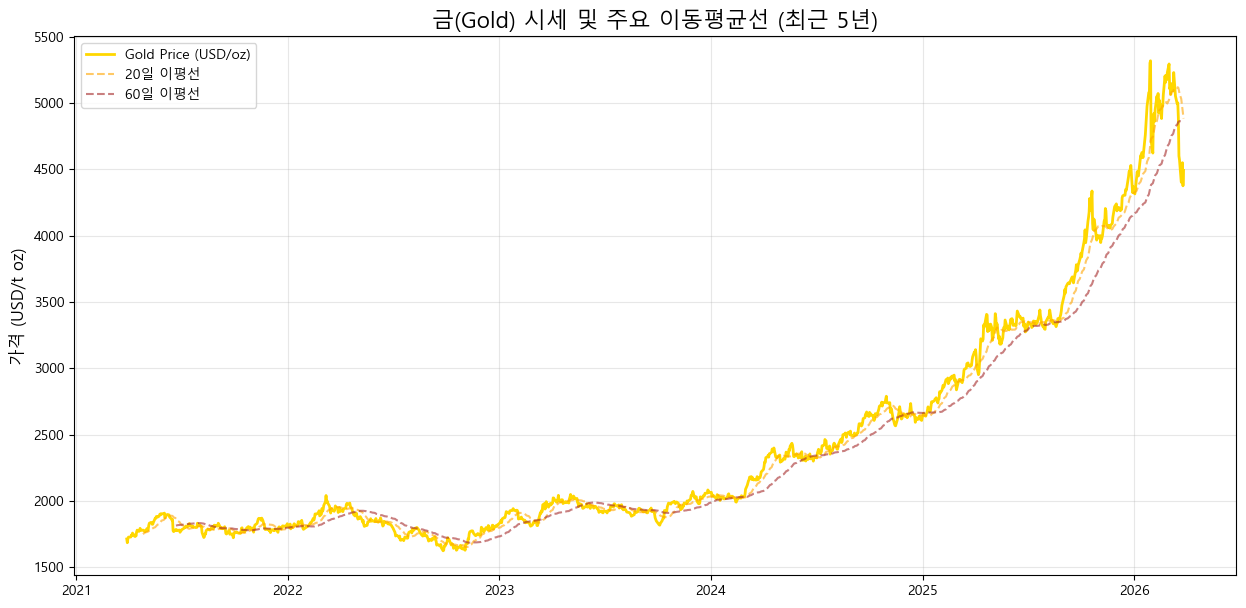

In [3]:
plt.figure(figsize=(15, 7))
plt.plot(gold_data['Close'], label='Gold Price (USD/oz)', color='gold', linewidth=2)
plt.plot(gold_data['MA20'], label='20일 이평선', color='orange', alpha=0.6, linestyle='--')
plt.plot(gold_data['MA60'], label='60일 이평선', color='brown', alpha=0.6, linestyle='--')

plt.title('금(Gold) 시세 및 주요 이동평균선 (최근 5년)', fontsize=16)
plt.ylabel('가격 (USD/t oz)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

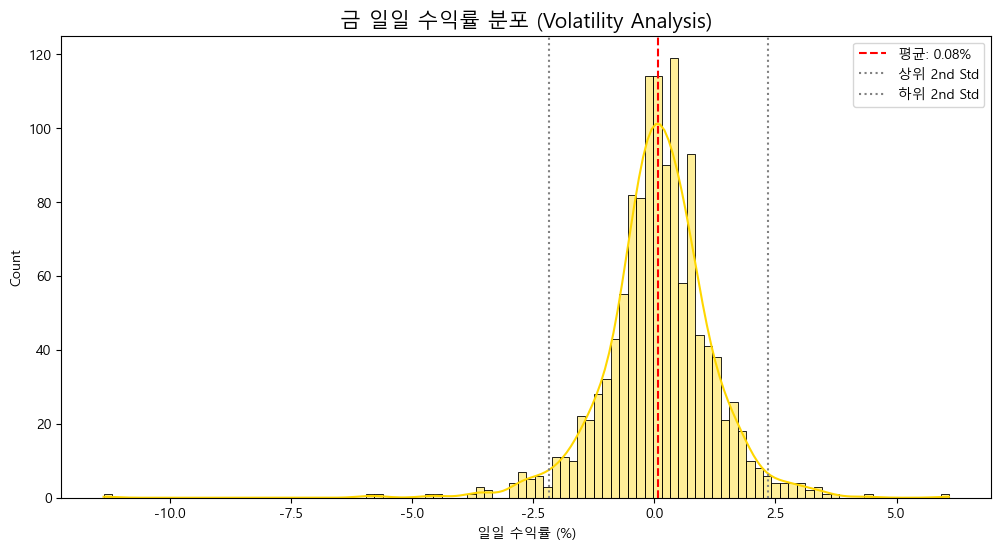

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(gold_data['Daily Return'].dropna(), bins=100, kde=True, color='gold', alpha=0.4)

# 통계치 표시
mean_val = gold_data['Daily Return'].mean()
std_val = gold_data['Daily Return'].std()

plt.axvline(mean_val, color='red', linestyle='--', label=f'평균: {mean_val:.2f}%')
plt.axvline(mean_val + 2*std_val, color='grey', linestyle=':', label='상위 2nd Std')
plt.axvline(mean_val - 2*std_val, color='grey', linestyle=':', label='하위 2nd Std')

plt.title('금 일일 수익률 분포 (Volatility Analysis)', fontsize=15)
plt.xlabel('일일 수익률 (%)')
plt.legend()
plt.show()

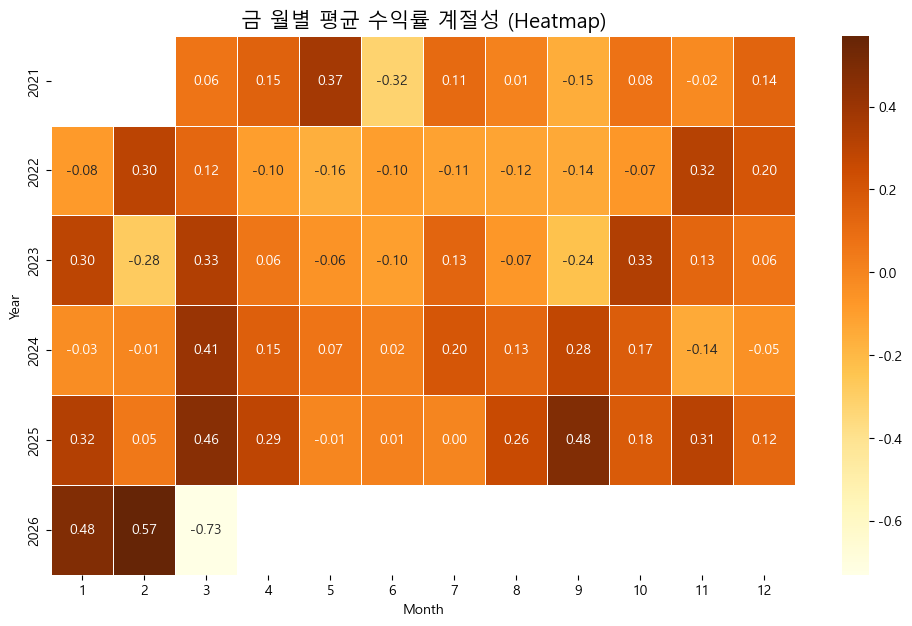

In [6]:
# 연도/월별 데이터 재구성
gold_season = gold_data[['Daily Return']].copy()

# [이 코드 한 줄을 추가해 주세요]
# 멀티인덱스 구조를 해제하여 'Year', 'Month' 컬럼 추가 시 발생하는 타입 충돌을 방지합니다.
if isinstance(gold_season.columns, pd.MultiIndex):
    gold_season.columns = gold_season.columns.get_level_values(0)

gold_season['Year'] = gold_season.index.year
gold_season['Month'] = gold_season.index.month

# 이제 pivot_table이 정상적으로 작동합니다.
pivot_gold = gold_season.pivot_table(values='Daily Return', index='Year', columns='Month', aggfunc='mean')

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_gold, annot=True, cmap='YlOrBr', fmt=".2f", linewidths=.5)
plt.title('금 월별 평균 수익률 계절성 (Heatmap)', fontsize=15)
plt.show()
